In [4]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import os
import math

from ultralytics import YOLO
from shapely.geometry import Point, Polygon

warnings.filterwarnings("ignore")

print("=" * 60)
print(" PROACT AI - People Counting Assignment ")
print("=" * 60)
print("Libraries Loaded Successfully ✅")

 PROACT AI - People Counting Assignment 
Libraries Loaded Successfully ✅


In [5]:
import ultralytics
import torch
import insightface

print("Python      :", os.sys.version)
print("PyTorch     :", torch.__version__)
print("OpenCV      :", cv2.__version__)
print("Ultralytics :", ultralytics.__version__)
print("InsightFace :", insightface.__version__)

Python      : 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
PyTorch     : 2.12.1+cpu
OpenCV      : 4.8.1
Ultralytics : 8.4.86
InsightFace : 1.0.1


In [6]:
MODEL_PATH = "yolo11n.pt"

model = YOLO(MODEL_PATH)

print("YOLO11 Model Loaded Successfully ✅")

YOLO11 Model Loaded Successfully ✅


In [7]:
VIDEO_PATH = "TownCentreXVID.mp4"

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise Exception("Unable to Open Video")

fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("=" * 50)
print("Video Loaded Successfully")
print("=" * 50)
print("Resolution :", width, "x", height)
print("FPS        :", fps)
print("Frames     :", total_frames)

Video Loaded Successfully
Resolution : 1920 x 1080
FPS        : 25
Frames     : 7502


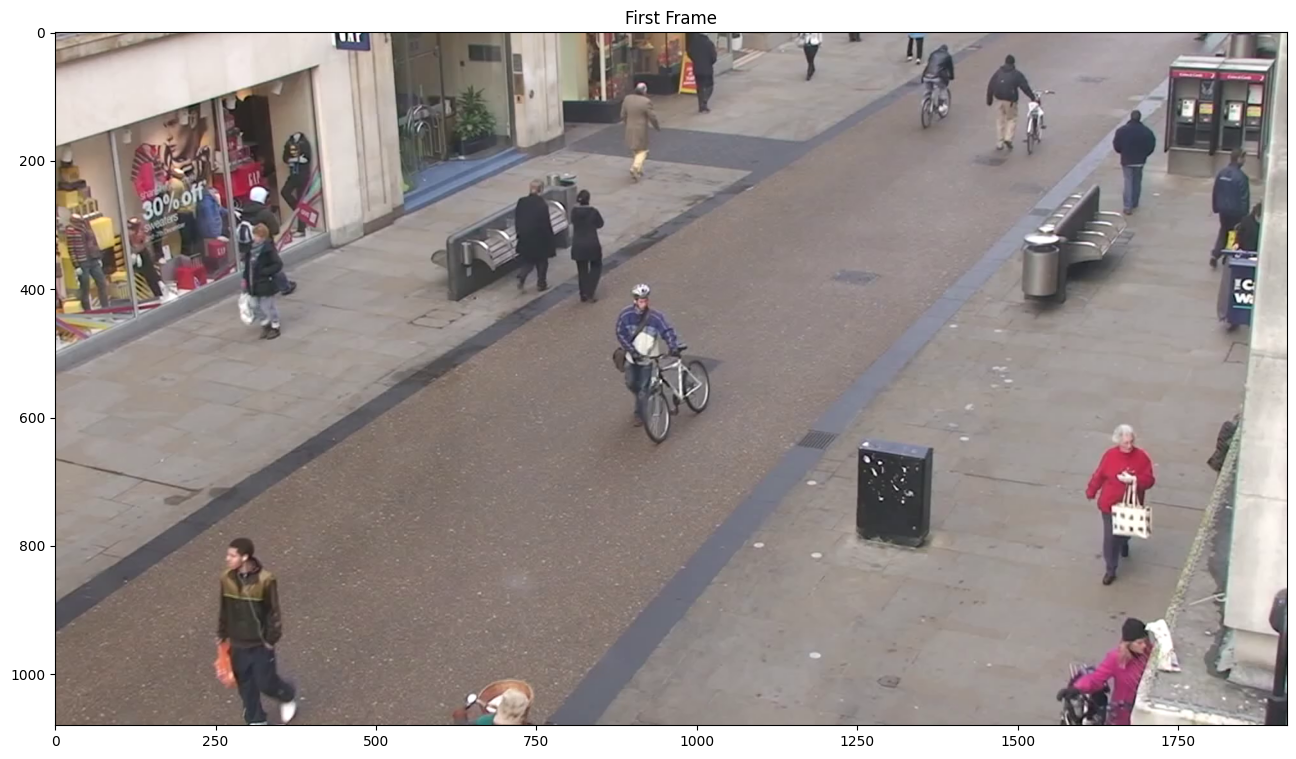

In [8]:
ret, frame = cap.read()

if not ret:
    raise Exception("Cannot Read First Frame")

plt.figure(figsize=(16, 9))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title("First Frame")
plt.axis("on")
plt.show()

In [9]:
polygon_points = []

display = frame.copy()


def mouse(event, x, y, flags, param):

    global display

    if event == cv2.EVENT_LBUTTONDOWN:

        if len(polygon_points) < 4:

            polygon_points.append((x, y))

            cv2.circle(display, (x, y), 6, (0, 0, 255), -1)

            cv2.putText(
                display,
                str(len(polygon_points)),
                (x + 8, y - 8),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 255, 0),
                2
            )

            if len(polygon_points) > 1:

                cv2.line(
                    display,
                    polygon_points[-2],
                    polygon_points[-1],
                    (0,255,0),
                    2
                )

            if len(polygon_points) == 4:

                cv2.line(
                    display,
                    polygon_points[-1],
                    polygon_points[0],
                    (0,255,0),
                    2
                )


cv2.namedWindow("Polygon Selector", cv2.WINDOW_NORMAL)

cv2.imshow("Polygon Selector", display)

cv2.setMouseCallback("Polygon Selector", mouse)

print("="*60)
print("Click 4 Points")
print("1.Top Left")
print("2.Top Right")
print("3.Bottom Right")
print("4.Bottom Left")
print("Press ENTER to Finish")
print("Press R to Reset")
print("="*60)

while True:

    cv2.imshow("Polygon Selector", display)

    key = cv2.waitKey(1) & 0xFF

    if key == ord("r"):

        polygon_points.clear()

        display = frame.copy()

    elif key == 13:

        if len(polygon_points) == 4:
            break

        print("Please Select 4 Points")

cv2.destroyAllWindows()

print(polygon_points)

Click 4 Points
1.Top Left
2.Top Right
3.Bottom Right
4.Bottom Left
Press ENTER to Finish
Press R to Reset
[(796, 181), (869, 142), (1165, 172), (1084, 218)]


In [10]:
polygon = np.array([
    [796,181],
    [869,142],
    [1165,172],
    [1084,218]
], dtype=np.int32)

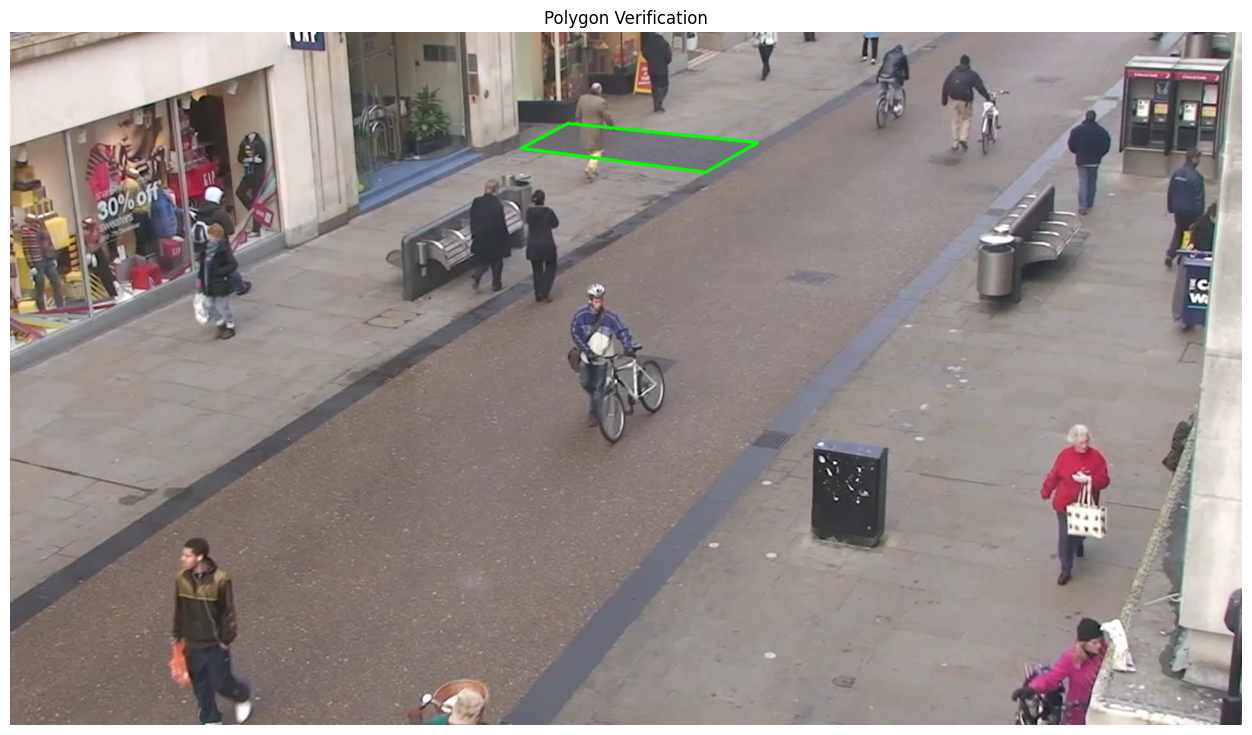

In [11]:
temp = frame.copy()

cv2.polylines(
    temp,
    [polygon],
    True,
    (0,255,0),
    3
)

plt.figure(figsize=(16,9))

plt.imshow(cv2.cvtColor(temp, cv2.COLOR_BGR2RGB))

plt.title("Polygon Verification")

plt.axis("off")

plt.show()

In [20]:
cap.release()

cap = cv2.VideoCapture(VIDEO_PATH)

fps = int(cap.get(cv2.CAP_PROP_FPS))

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(
    "output.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width,height)
)

poly = Polygon(polygon)

frame_no = 0

left_to_right = 0

male_count = 0

female_count = 0

previous_centers = {}

counted_ids = set()

gender_memory = {}

csv_data = []

print("Tracking Variables Initialized ✅")

Tracking Variables Initialized ✅


In [21]:
print(cap.isOpened())

ret, test_frame = cap.read()

print("ret =", ret)

if ret:
    print(test_frame.shape)

cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

True
ret = True
(1080, 1920, 3)


True

In [22]:
from insightface.app import FaceAnalysis

face_app = FaceAnalysis(
    name="buffalo_l",
    providers=["CPUExecutionProvider"]
)

face_app.prepare(
    ctx_id=0,
    det_size=(640, 640)
)

print("=" * 50)
print("InsightFace Loaded Successfully ✅")
print("=" * 50)

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\harsh mishra/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\harsh mishra/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\harsh mishra/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\harsh mishra/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\harsh mishra/.insightface\models\buffalo_l\w600k_r50.onnx rec

In [23]:
def predict_gender(person_crop):
    """
    Predict Gender using InsightFace
    Returns:
        Male / Female / Unknown
    """

    if person_crop is None:
        return "Unknown"

    if person_crop.size == 0:
        return "Unknown"

    h, w = person_crop.shape[:2]

    # Ignore very small crops
    if h < 40 or w < 40:
        return "Unknown"

    try:

        faces = face_app.get(person_crop)

        if len(faces) == 0:
            return "Unknown"

        gender = faces[0].gender

        # InsightFace:
        # 0 = Female
        # 1 = Male

        if gender == 1:
            return "Male"
        else:
            return "Female"

    except Exception:
        return "Unknown"

In [24]:
def crop_person(frame, x1, y1, x2, y2):

    h, w = frame.shape[:2]

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w, x2)
    y2 = min(h, y2)

    return frame[y1:y2, x1:x2]

In [25]:
while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_no += 1

    display = frame.copy()

    # -------------------------------
    # YOLO + ByteTrack
    # -------------------------------
    results = model.track(
        frame,
        persist=True,
        tracker="bytetrack.yaml",
        classes=[0],
        conf=0.35,
        verbose=False
    )

    # Draw Polygon
    cv2.polylines(
        display,
        [polygon],
        True,
        (0,255,0),
        3
    )

    # No detections
    if results[0].boxes.id is None:

        cv2.putText(
            display,
            f"Male : {male_count}",
            (20,40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (255,0,0),
            2
        )

        cv2.putText(
            display,
            f"Female : {female_count}",
            (20,80),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (255,0,255),
            2
        )

        cv2.putText(
            display,
            f"Total : {left_to_right}",
            (20,120),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0,0,255),
            2
        )

        out.write(display)

        cv2.imshow("PROACT AI", display)

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

        continue

    # -------------------------------
    # Detection Data
    # -------------------------------
    boxes = results[0].boxes.xyxy.cpu().numpy()

    ids = results[0].boxes.id.cpu().numpy().astype(int)

    # Process every tracked person
    for box, track_id in zip(boxes, ids):

        x1, y1, x2, y2 = map(int, box)

        cx = (x1 + x2) // 2
        cy = (y1 + y2) // 2

        center = (cx, cy)

        # Crop person for gender prediction
        person_crop = crop_person(
            frame,
            x1,
            y1,
            x2,
            y2
        )
                # ---------------------------------
        # Gender Prediction (Only Once Per ID)
        # ---------------------------------

        if track_id not in gender_memory:

            gender = predict_gender(person_crop)

            gender_memory[track_id] = gender

        else:

            gender = gender_memory[track_id]

        # ---------------------------------
        # Draw Bounding Box
        # ---------------------------------

        if gender == "Male":

            box_color = (255, 0, 0)

        elif gender == "Female":

            box_color = (255, 0, 255)

        else:

            box_color = (0, 255, 255)

        cv2.rectangle(
            display,
            (x1, y1),
            (x2, y2),
            box_color,
            2
        )

        cv2.circle(
            display,
            center,
            4,
            (0, 255, 255),
            -1
        )

        cv2.putText(
            display,
            f"ID {track_id}",
            (x1, y1 - 25),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            box_color,
            2
        )

        cv2.putText(
            display,
            gender,
            (x1, y1 - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            box_color,
            2
        )

        # ---------------------------------
        # First Appearance
        # ---------------------------------

        if track_id not in previous_centers:

            previous_centers[track_id] = center

            continue

        prev = previous_centers[track_id]

        previous_centers[track_id] = center

                # ---------------------------------
        # Skip if already counted
        # ---------------------------------

        if track_id in counted_ids:
            continue

        inside_prev = poly.contains(Point(prev))
        inside_now = poly.contains(Point(center))

        # Count only when person exits polygon
        if inside_prev and not inside_now:

            # Left → Right movement
            if center[0] > prev[0]:

                left_to_right += 1

                counted_ids.add(track_id)

                # Count Gender
                if gender == "Male":

                    male_count += 1

                elif gender == "Female":

                    female_count += 1

                # Save CSV Record
                csv_data.append({

                    "Frame": frame_no,

                    "Track_ID": int(track_id),

                    "Gender": gender,

                    "Direction": "Left_to_Right"

                })

                print(
                    f"Frame:{frame_no} | "
                    f"ID:{track_id} | "
                    f"{gender} | "
                    f"Male:{male_count} | "
                    f"Female:{female_count} | "
                    f"Total:{left_to_right}"
                )
    # ---------------------------------
    # Display Live Counts
    # ---------------------------------

    cv2.putText(
        display,
        f"Male : {male_count}",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255, 0, 0),
        2
    )

    cv2.putText(
        display,
        f"Female : {female_count}",
        (20, 80),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255, 0, 255),
        2
    )

    cv2.putText(
        display,
        f"Total : {left_to_right}",
        (20, 120),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 0, 255),
        2
    )

    # ---------------------------------
    # Save Output Video
    # ---------------------------------

    out.write(display)

    # ---------------------------------
    # Show Video
    # ---------------------------------

    cv2.imshow("PROACT AI - People Counter", display)

    # ---------------------------------
    # Exit
    # ---------------------------------

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

# ================================
# Release Resources
# ================================

cap.release()

out.release()

cv2.destroyAllWindows()

print("=" * 60)
print("Processing Completed Successfully ✅")
print("=" * 60)
print(f"Male Count   : {male_count}")
print(f"Female Count : {female_count}")
print(f"Total Count  : {left_to_right}")
print("=" * 60)

Frame:16 | ID:1537 | Unknown | Male:0 | Female:0 | Total:1
Frame:125 | ID:1534 | Unknown | Male:0 | Female:0 | Total:2
Frame:127 | ID:1538 | Unknown | Male:0 | Female:0 | Total:3
Frame:439 | ID:1606 | Unknown | Male:0 | Female:0 | Total:4
Frame:548 | ID:1634 | Unknown | Male:0 | Female:0 | Total:5
Frame:659 | ID:1613 | Unknown | Male:0 | Female:0 | Total:6
Frame:762 | ID:1669 | Unknown | Male:0 | Female:0 | Total:7
Frame:780 | ID:1671 | Unknown | Male:0 | Female:0 | Total:8
Frame:795 | ID:1622 | Unknown | Male:0 | Female:0 | Total:9
Frame:1159 | ID:1713 | Male | Male:1 | Female:0 | Total:10
Frame:1382 | ID:1756 | Unknown | Male:1 | Female:0 | Total:11
Frame:1471 | ID:1873 | Unknown | Male:1 | Female:0 | Total:12
Frame:1477 | ID:1831 | Unknown | Male:1 | Female:0 | Total:13
Frame:1480 | ID:1785 | Unknown | Male:1 | Female:0 | Total:14
Frame:1490 | ID:1874 | Unknown | Male:1 | Female:0 | Total:15
Frame:1601 | ID:1889 | Unknown | Male:1 | Female:0 | Total:16
Frame:1773 | ID:1923 | Unknown

In [26]:
df = pd.DataFrame(csv_data)

df.to_csv("People_Count.csv", index=False)

print(df.head())

   Frame  Track_ID   Gender      Direction
0     16      1537  Unknown  Left_to_Right
1    125      1534  Unknown  Left_to_Right
2    127      1538  Unknown  Left_to_Right
3    439      1606  Unknown  Left_to_Right
4    548      1634  Unknown  Left_to_Right


In [27]:
print("="*60)
print("PROACT AI Assignment Completed Successfully")
print("="*60)
print("Male Count   :", male_count)
print("Female Count :", female_count)
print("Total Count  :", left_to_right)
print("CSV Saved    : People_Count.csv")
print("Video Saved  : output.mp4")
print("="*60)

PROACT AI Assignment Completed Successfully
Male Count   : 3
Female Count : 1
Total Count  : 50
CSV Saved    : People_Count.csv
Video Saved  : output.mp4
